### Trabalho Fase 1 do Curso de Pós-Graduação FIAP IA para Devs
#### Parte 2 - Dados Gerais - Tratamento de dados

**Objetivo geral - Avaliação geral dos dados SIH/RD e seus respectivos tratamentos**

Organizar a base reduzida do SIH/SUS RD, avaliar a qualidade dos dados, tratar colunas textuais e diagnósticas, criar representações numéricas e preparar a base para etapas exploratórias e modelos de machine learning, tendo a coluna `CANCER_MAMA_NIVEL` como target principal.

---

## Sumário da Parte 2

**Item 1 - Dicionário de dados e leitura da base reduzida**

- **1.1 - Consulta do dicionário após a redução inicial**
- **1.2 - Carregamento da base `2025_reduzido.parquet`**
- **1.3 - Conferência do shape da base**
- **1.4 - Verificação dos tipos de dados e uso de memória**

**Item 2 - Verificação dos nulos**

- **2.1 - Avaliação de dados nulos e vazios**
- **2.2 - Tratamento de nulos e vazios**

**Item 3 - Análises relacionais gerais e validação de integridade dos dados**

- **3.1 - Recorte das internações do ano de 2025**
- **3.2 - Criação de label para a coluna sexo**
- **3.3 - Tratamento da coluna idade**
- **3.4 - Comparação geral com a distribuição populacional**

**Item 4 - Avaliação e tratamento das colunas do tipo string**

- **4.1 - Verificação dos tipos de dados e identificação de colunas especiais**
- **4.2 - Avaliação descritiva das colunas após identificação dos tipos**
- **4.3 - Remoção de colunas textuais sem confiabilidade suficiente para o recorte**

**Item 5 - Tratamento dos campos CID**

- **5.1 - Validação do formato dos campos CID mantidos no recorte**
- **5.2 - Geração de representações numéricas para os campos CID**
- **5.3 - Categorização do CID do diagnóstico principal**

**Item 6 - Identificação e agrupamento de câncer de mama em todos os campos CID**

- **6.1 - Criação dos níveis de indício de câncer de mama para definir `CANCER_MAMA_NIVEL` como target principal**
- **6.2 - Consolidação do maior nível encontrado entre os campos CID**

**Item 7 - Identificação e agrupamento de violência contra mulher em todos os campos CID**

- **7.1 - Criação dos níveis de indício de violência contra mulher para definir `VIOLENCIA_MULHER_NIVEL` como target alternativo ou de contingência**
- **7.2 - Consolidação do maior nível encontrado entre os campos CID**

**Item 8 - Tratamento da coluna do mês**

- **8.1 - Avaliação das competências registradas**
- **8.2 - Validação da coluna `MES_CMPT` no formato MM**

**Item 9 - Geração da base tratada final**

- **9.1 - Remoção de colunas temporárias e que não serão utilizadas**
- **9.2 - Geração do arquivo Parquet final tratado**
- **9.3 - Validação dos tipos finais e da estrutura da base tratada**

#### Item 1 - Dicionário de Dados - SIH/SUS RD após redução inicial

**Neste passo vamos consultar o dicionário da base reduzida antes de iniciar os tratamentos.**

A base `2025_reduzido.parquet` contém **925.240 registros** e **54 colunas**. O dicionário abaixo corresponde às colunas efetivamente presentes no arquivo reduzido.

| Ordem | Coluna | Descrição |
|---:|---|---|
| 1 | MES_CMPT | Mês de competência/processamento da informação, no formato mm. |
| 2 | IDENT | Identificação do tipo de AIH. |
| 3 | MUNIC_RES | Código IBGE do município de residência do paciente. |
| 4 | NASC | Data de nascimento do paciente, no formato aaaammdd. |
| 5 | SEXO | Sexo do paciente: 1 masculino; 3 feminino. |
| 6 | COD_IDADE | Unidade de medida usada para interpretar a idade informada. |
| 7 | IDADE | Idade do paciente conforme a unidade indicada em COD_IDADE. |
| 8 | NUM_FILHOS | Quantidade de filhos informada no registro. |
| 9 | INSTRU | Grau de instrução do paciente. |
| 10 | GESTRISCO | Indicador de gestante de alto risco. |
| 11 | CONTRACEP1 | Método contraceptivo informado no campo 1. |
| 12 | CONTRACEP2 | Método contraceptivo informado no campo 2. |
| 13 | RACA_COR | Raça/cor do paciente. |
| 14 | ETNIA | Etnia do paciente, quando aplicável. |
| 15 | DT_INTER | Data da internação, no formato aaaammdd. |
| 16 | DT_SAIDA | Data da saída/alta, no formato aaaammdd. |
| 17 | DIAS_PERM | Quantidade de dias de permanência. |
| 18 | QT_DIARIAS | Quantidade de diárias da internação. |
| 19 | UTI_MES_IN | Quantidade de dias de UTI no mês inicial da internação. |
| 20 | UTI_MES_AN | Quantidade de dias de UTI em mês anterior ao mês da alta. |
| 21 | UTI_MES_AL | Quantidade de dias de UTI no mês da alta. |
| 22 | UTI_MES_TO | Quantidade total de dias/atos de UTI. |
| 23 | UTI_INT_IN | Dias em unidade intermediária no mês inicial da internação. |
| 24 | UTI_INT_AN | Dias em unidade intermediária em mês anterior ao mês da alta. |
| 25 | UTI_INT_AL | Dias em unidade intermediária no mês da alta. |
| 26 | UTI_INT_TO | Total de dias em unidade intermediária. |
| 27 | MORTE | Indicador de óbito associado à internação. |
| 28 | PROC_REA | Código do procedimento realizado. |
| 29 | DIAG_PRINC | Diagnóstico principal informado, em código CID. |
| 30 | DIAG_SECUN | Diagnóstico secundário informado, em código CID. |
| 31 | CID_NOTIF | CID de notificação. |
| 32 | CID_ASSO | CID associado/causa. |
| 33 | CID_MORTE | CID associado ao óbito. |
| 34 | DIAGSEC1 | Diagnóstico secundário 1, em código CID. |
| 35 | DIAGSEC2 | Diagnóstico secundário 2, em código CID. |
| 36 | DIAGSEC3 | Diagnóstico secundário 3, em código CID. |
| 37 | DIAGSEC4 | Diagnóstico secundário 4, em código CID. |
| 38 | DIAGSEC5 | Diagnóstico secundário 5, em código CID. |
| 39 | DIAGSEC6 | Diagnóstico secundário 6, em código CID. |
| 40 | DIAGSEC7 | Diagnóstico secundário 7, em código CID. |
| 41 | DIAGSEC8 | Diagnóstico secundário 8, em código CID. |
| 42 | DIAGSEC9 | Diagnóstico secundário 9, em código CID. |
| 43 | TPDISEC1 | Tipo/classificação do diagnóstico secundário 1. |
| 44 | TPDISEC2 | Tipo/classificação do diagnóstico secundário 2. |
| 45 | TPDISEC3 | Tipo/classificação do diagnóstico secundário 3. |
| 46 | TPDISEC4 | Tipo/classificação do diagnóstico secundário 4. |
| 47 | TPDISEC5 | Tipo/classificação do diagnóstico secundário 5. |
| 48 | TPDISEC6 | Tipo/classificação do diagnóstico secundário 6. |
| 49 | TPDISEC7 | Tipo/classificação do diagnóstico secundário 7. |
| 50 | TPDISEC8 | Tipo/classificação do diagnóstico secundário 8. |
| 51 | TPDISEC9 | Tipo/classificação do diagnóstico secundário 9. |
| 52 | COMPLEX | Complexidade do procedimento/atendimento. |
| 53 | VAL_TOT | Valor total aprovado/pago da AIH. |
| 54 | DIAR_ACOM | Quantidade de diárias de acompanhante. |

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import re

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

dados = pd.read_parquet("2025_reduzido.parquet")
dados.head()


,MES_CMPT,IDENT,MUNIC_RES,NASC,SEXO,COD_IDADE,IDADE,NUM_FILHOS,INSTRU,GESTRISCO,CONTRACEP1,CONTRACEP2,RACA_COR,ETNIA,MUNIC_MOV,DT_INTER,DT_SAIDA,DIAS_PERM,QT_DIARIAS,UTI_MES_IN,UTI_MES_AN,UTI_MES_AL,UTI_MES_TO,UTI_INT_IN,UTI_INT_AN,UTI_INT_AL,UTI_INT_TO,MORTE,PROC_REA,DIAG_PRINC,DIAG_SECUN,CID_NOTIF,CID_ASSO,CID_MORTE,DIAGSEC1,DIAGSEC2,DIAGSEC3,DIAGSEC4,DIAGSEC5,DIAGSEC6,DIAGSEC7,DIAGSEC8,DIAGSEC9,TPDISEC1,TPDISEC2,TPDISEC3,TPDISEC4,TPDISEC5,TPDISEC6,TPDISEC7,TPDISEC8,TPDISEC9,COMPLEX,VAL_TOT,DIAR_ACOM
0,01,1,330455,20150219,3,4,9,0,0,1,00,00,01,0000,330455,20241211,20241213,2,2,0,0,0,0,0,0,0,0,0,0304080020,C829,0000,,0000,0000,,,,,,,,,,0,0,0,0,0,0,0,0,0,03,1183.86,2
1,01,1,330170,20180804,1,4,6,0,0,1,00,00,03,0000,330455,20241225,20241230,5,5,0,0,0,0,0,0,0,0,0,0304100013,C910,0000,,0000,0000,,,,,,,,,,0,0,0,0,0,0,0,0,0,02,299.95,5
2,01,1,330170,19670412,1,4,57,0,0,1,00,00,01,0000,330455,20241219,20241227,8,9,0,0,0,0,0,0,0,0,0,0304100013,C910,0000,,0000,0000,,,,,,,,,,0,0,0,0,0,0,0,0,0,02,1664.40,0
3,01,1,330045,19640923,3,4,60,0,0,1,00,00,03,0000,330455,20241214,20241231,17,17,0,0,0,0,0,0,0,0,0,0303020040,D570,0000,,0000,0000,J989,,,,,,,,,2,0,0,0,0,0,0,0,0,02,7046.64,7
4,01,1,330630,20040414,1,4,20,0,0,1,00,00,03,0000,330455,20241224,20241231,7,7,0,0,0,0,0,0,0,0,0,0303020040,D571,0000,,0000,0000,,,,,,,,,,0,0,0,0,0,0,0,0,0,02,973.62,0


In [2]:
dados.shape

(925240, 55)

In [3]:
dados.info()

<class 'pandas.DataFrame'>
RangeIndex: 925240 entries, 0 to 925239
Data columns (total 55 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   MES_CMPT    925240 non-null  str    
 1   IDENT       925240 non-null  str    
 2   MUNIC_RES   925240 non-null  str    
 3   NASC        925240 non-null  str    
 4   SEXO        925240 non-null  str    
 5   COD_IDADE   925240 non-null  str    
 6   IDADE       925240 non-null  int64  
 7   NUM_FILHOS  925240 non-null  int64  
 8   INSTRU      925240 non-null  str    
 9   GESTRISCO   925240 non-null  str    
 10  CONTRACEP1  925240 non-null  str    
 11  CONTRACEP2  925240 non-null  str    
 12  RACA_COR    925240 non-null  str    
 13  ETNIA       925240 non-null  str    
 14  MUNIC_MOV   925240 non-null  str    
 15  DT_INTER    925240 non-null  str    
 16  DT_SAIDA    925240 non-null  str    
 17  DIAS_PERM   925240 non-null  int64  
 18  QT_DIARIAS  925240 non-null  int64  
 19  UTI_MES_IN  9

#### Item 2 - Verificação dos nulos

**Neste passo vamos:**

- **2.1 - Avaliar dados nulos e vazios**
- **2.2 - Tratar os dados nulos e vazios**


##### 2.1 - Avaliação de nulos e vazios


In [4]:
dados.isna().sum()

MES_CMPT      0
IDENT         0
MUNIC_RES     0
NASC          0
SEXO          0
COD_IDADE     0
IDADE         0
NUM_FILHOS    0
INSTRU        0
GESTRISCO     0
CONTRACEP1    0
CONTRACEP2    0
RACA_COR      0
ETNIA         0
MUNIC_MOV     0
DT_INTER      0
DT_SAIDA      0
DIAS_PERM     0
QT_DIARIAS    0
UTI_MES_IN    0
UTI_MES_AN    0
UTI_MES_AL    0
UTI_MES_TO    0
UTI_INT_IN    0
UTI_INT_AN    0
UTI_INT_AL    0
UTI_INT_TO    0
MORTE         0
PROC_REA      0
DIAG_PRINC    0
DIAG_SECUN    0
CID_NOTIF     0
CID_ASSO      0
CID_MORTE     0
DIAGSEC1      0
DIAGSEC2      0
DIAGSEC3      0
DIAGSEC4      0
DIAGSEC5      0
DIAGSEC6      0
DIAGSEC7      0
DIAGSEC8      0
DIAGSEC9      0
TPDISEC1      0
TPDISEC2      0
TPDISEC3      0
TPDISEC4      0
TPDISEC5      0
TPDISEC6      0
TPDISEC7      0
TPDISEC8      0
TPDISEC9      0
COMPLEX       0
VAL_TOT       0
DIAR_ACOM     0
dtype: int64

In [5]:
possuiNulos = []
for coluna in dados.columns:
    qtdNulos = dados[coluna].isna().sum()
    
    qtdVazios = (
        dados[coluna]
        .fillna("")
        .astype(str)
        .str.strip()
        .eq("")
        .sum()
    )

    if(qtdNulos > 0):
        print(f"Coluna {coluna} possuí {qtdNulos} registros nulos.")

    if(qtdVazios > 0):
        print(f"Coluna {coluna} possuí {qtdVazios} registros vazios.")

Coluna CID_NOTIF possuí 887662 registros vazios.
Coluna DIAGSEC1 possuí 722288 registros vazios.
Coluna DIAGSEC2 possuí 891839 registros vazios.
Coluna DIAGSEC3 possuí 909121 registros vazios.
Coluna DIAGSEC4 possuí 917761 registros vazios.
Coluna DIAGSEC5 possuí 922036 registros vazios.
Coluna DIAGSEC6 possuí 923862 registros vazios.
Coluna DIAGSEC7 possuí 924726 registros vazios.
Coluna DIAGSEC8 possuí 925100 registros vazios.
Coluna DIAGSEC9 possuí 925196 registros vazios.


##### 2.2 - Tratamento de nulos e vazios

Podemos observar que não há valores nulos, mas há colunas com registros vazios, todas relacionadas aos CIDs. Faremos a tratativa dos CIDs em etapa posterior.


- **As colunas que informam CID serão tratadas posteriormente.**


#### Item 3 - Análises relacionais gerais e validação de integridade dos dados

**Neste passo vamos:**

- **3.1 - Manter apenas internações do ano de 2025**
- **3.2 - Criar label para a coluna sexo**
- **3.3 - Tratar a coluna idade**
- **3.4 - Comparar a base de atendimentos com a distribuição populacional usada como referência**


##### 3.1 - Recorte das internações do ano de 2025


In [6]:
dados.groupby(dados["DT_INTER"].str[0:4]).size()

DT_INTER
2012        68
2013       109
2014        51
2015        82
2016       595
2017        77
2018       100
2019       202
2020       294
2021       377
2022       386
2023       535
2024     64638
2025    857726
dtype: int64

In [7]:
dados = dados[dados["DT_INTER"].str[0:4]=='2025']

##### 3.2 - Criação de label para a coluna sexo


In [8]:
dados.groupby("SEXO").size()


SEXO
1    361095
3    496631
dtype: int64

In [9]:
mapa = {
    "0": "ND",
    "1": "Masculino",
    "3": "Feminino"
}

dados["SEXO_LABEL"] = dados["SEXO"].astype(str).map(mapa)
dados.groupby("SEXO_LABEL").size()

SEXO_LABEL
Feminino     496631
Masculino    361095
dtype: int64

##### 3.3 - Tratamento da coluna idade


In [10]:
dados["NASC_DT"] = pd.to_datetime(dados["NASC"], format="%Y%m%d", errors="coerce")
dados["ANO_NASC"] = dados["NASC_DT"].dt.year

In [11]:
dados.query("COD_IDADE != '4'").groupby("ANO_NASC").size()

ANO_NASC
1897        2
1900        7
1907        2
1910        1
1911        2
1914        1
1915        9
1916        2
1917       11
1918        3
1919       13
1920       29
1921       30
1922       77
1923      130
1924      145
1925       98
2024     6991
2025    34984
dtype: int64

In [12]:
def idade_em_anos(row) -> int:
    idade = int(row["IDADE"])
    cod = int(row["COD_IDADE"])
    anoNasc = int(row["ANO_NASC"])

    retorno: int = -1

    if anoNasc < 1925:
        return 100
    
    if anoNasc < 1925:
        return 100
    
    if cod !=4 and anoNasc >= 2024:
        return 0
    
    if cod !=4 and anoNasc < 2024:
        return idade

    if cod == 2:
        retorno = idade / 365
    elif cod == 3:
        retorno = idade / 12
    elif cod == 4:
        retorno = idade
    elif cod == 5:
        retorno = 100

    return int(retorno)    
   

dados["IDADE_ANOS"] = dados.apply(idade_em_anos, axis=1)


In [13]:
dados.groupby("ANO_NASC")["IDADE_ANOS"].unique()

ANO_NASC
1897       [100]
1900       [100]
1907       [100]
1910       [100]
1911       [100]
1914       [100]
1915       [100]
1916       [100]
1917       [100]
1918       [100]
1919       [100]
1920       [100]
1921       [100]
1922       [100]
1923       [100]
1924       [100]
1925     [99, 0]
1926    [98, 99]
1927    [97, 98]
1928    [96, 97]
1929    [95, 96]
1930    [94, 95]
1931    [93, 94]
1932    [92, 93]
1933    [91, 92]
1934    [90, 91]
1935    [89, 90]
1936    [89, 88]
1937    [87, 88]
1938    [86, 87]
1939    [85, 86]
1940    [84, 85]
1941    [83, 84]
1942    [82, 83]
1943    [81, 82]
1944    [80, 81]
1945    [79, 80]
1946    [78, 79]
1947    [77, 78]
1948    [76, 77]
1949    [75, 76]
1950    [74, 75]
1951    [73, 74]
1952    [72, 73]
1953    [71, 72]
1954    [70, 71]
1955    [69, 70]
1956    [68, 69]
1957    [67, 68]
1958    [66, 67]
1959    [65, 66]
1960    [64, 65]
1961    [63, 64]
1962    [62, 63]
1963    [61, 62]
1964    [60, 61]
1965    [59, 60]
1966    [58, 59]
1967 

**Nossos dados referentes à idade estão tratados e confiáveis.**


##### 3.4 - Comparação geral dos dados e avaliação de integridade

Vamos comparar nossa base de atendimentos, qualificada por sexo e idade, com a distribuição populacional usada como referência no notebook de PA.


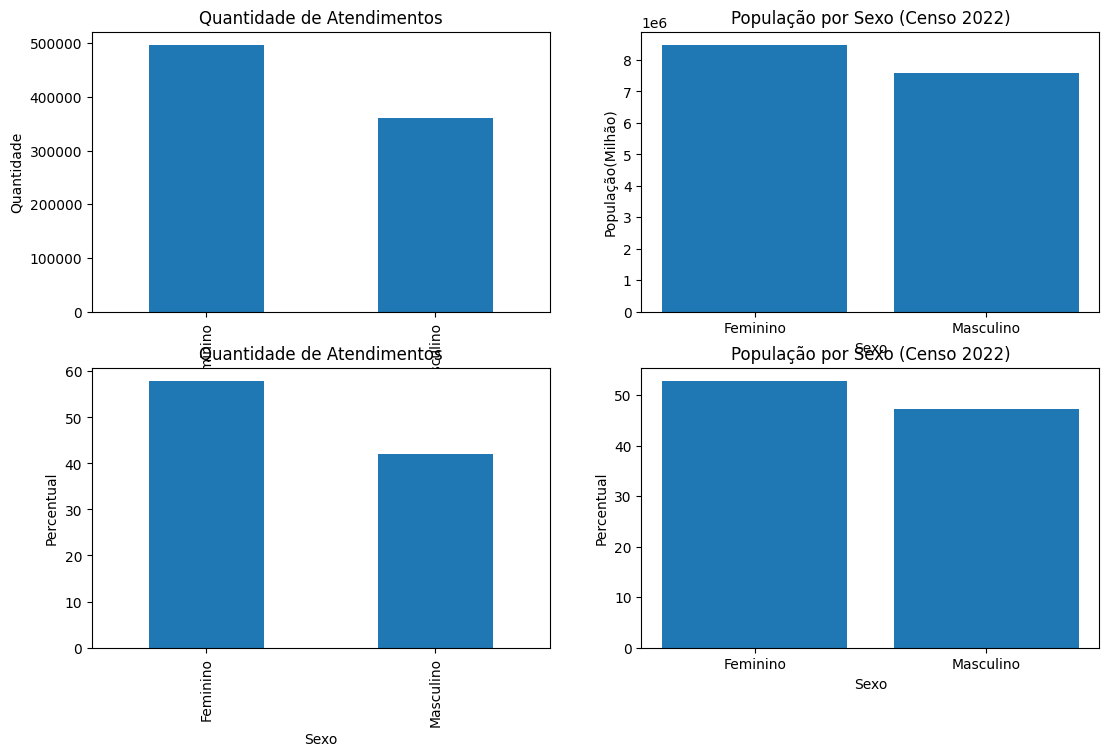

In [14]:
fig, axs = plt.subplots(2, 2, figsize=(13, 8))
histoQtdSexo = axs[0][0]
histoQtdPop = axs[0][1]
histoPercSexo = axs[1][0]
histoPercPop = axs[1][1]

dados["SEXO_LABEL"].value_counts().plot(kind="bar", ax=histoQtdSexo)
histoQtdSexo.set_title("Quantidade de Atendimentos")
histoQtdSexo.set_xlabel("Sexo")
histoQtdSexo.set_ylabel("Quantidade")

dadosPopolucaoQtd = {"Sexo": ["Feminino", "Masculino"], "Populacao": [8477499, 7577675]}
dadosPopolucaoQtd = pd.DataFrame(dadosPopolucaoQtd)
histoQtdPop.bar(dadosPopolucaoQtd["Sexo"], dadosPopolucaoQtd["Populacao"])
histoQtdPop.set_title("População por Sexo (Censo 2022)")
histoQtdPop.set_xlabel("Sexo")
histoQtdPop.set_ylabel("População(Milhão)")

(dados["SEXO_LABEL"].value_counts(normalize=True) * 100).plot(kind="bar", ax=histoPercSexo)
histoPercSexo.set_title("Quantidade de Atendimentos")
histoPercSexo.set_xlabel("Sexo")
histoPercSexo.set_ylabel("Percentual")

dadosPopolucaoPerc = {"Sexo": ["Feminino", "Masculino"], "Populacao": [52.8, 47.2]}
dadosPopolucaoPerc = pd.DataFrame(dadosPopolucaoPerc)
histoPercPop.bar(dadosPopolucaoPerc["Sexo"], dadosPopolucaoPerc["Populacao"])
histoPercPop.set_title("População por Sexo (Censo 2022)")
histoPercPop.set_xlabel("Sexo")
histoPercPop.set_ylabel("Percentual")

plt.show()


**Observação da comparação:** podemos perceber pelos gráficos que o perfil populacional dos atendimentos é compatível ao perfil populacional apresentado pelo IBGE, com uma variação positiva para o público feminino.


#### Item 4 - Avaliação e tratamento das colunas do tipo string

Algoritmos de ML trabalham apenas com números, por isso a importância de avaliar as colunas textuais e gerar representações numéricas quando fizer sentido.

**Neste passo vamos:**

- **4.1 - Verificar os tipos de dados e identificar colunas especiais**
- **4.2 - Avaliar a descrição geral das colunas após identificar os tipos**
- **4.3 - Remover colunas textuais sem confiabilidade suficiente para o recorte**


##### 4.1 - Verificação dos tipos de dados e identificação de colunas especiais


In [15]:
for coluna in dados.columns:
    print(f"{coluna} - {dados[coluna].dtype}")


MES_CMPT - str
IDENT - str
MUNIC_RES - str
NASC - str
SEXO - str
COD_IDADE - str
IDADE - int64
NUM_FILHOS - int64
INSTRU - str
GESTRISCO - str
CONTRACEP1 - str
CONTRACEP2 - str
RACA_COR - str
ETNIA - str
MUNIC_MOV - str
DT_INTER - str
DT_SAIDA - str
DIAS_PERM - int64
QT_DIARIAS - int64
UTI_MES_IN - int64
UTI_MES_AN - int64
UTI_MES_AL - int64
UTI_MES_TO - int64
UTI_INT_IN - int64
UTI_INT_AN - int64
UTI_INT_AL - int64
UTI_INT_TO - int64
MORTE - int64
PROC_REA - str
DIAG_PRINC - str
DIAG_SECUN - str
CID_NOTIF - str
CID_ASSO - str
CID_MORTE - str
DIAGSEC1 - str
DIAGSEC2 - str
DIAGSEC3 - str
DIAGSEC4 - str
DIAGSEC5 - str
DIAGSEC6 - str
DIAGSEC7 - str
DIAGSEC8 - str
DIAGSEC9 - str
TPDISEC1 - str
TPDISEC2 - str
TPDISEC3 - str
TPDISEC4 - str
TPDISEC5 - str
TPDISEC6 - str
TPDISEC7 - str
TPDISEC8 - str
TPDISEC9 - str
COMPLEX - str
VAL_TOT - float64
DIAR_ACOM - int64
SEXO_LABEL - str
NASC_DT - datetime64[us]
ANO_NASC - int32
IDADE_ANOS - int64


##### 4.2 - Avaliação descritiva das colunas após identificação dos tipos

Avaliamos a descrição geral da base para apoiar a decisão sobre colunas especiais, colunas textuais e próximos tratamentos.


In [16]:
dados.describe(include="all")


,MES_CMPT,IDENT,MUNIC_RES,NASC,SEXO,COD_IDADE,IDADE,NUM_FILHOS,INSTRU,GESTRISCO,CONTRACEP1,CONTRACEP2,RACA_COR,ETNIA,MUNIC_MOV,DT_INTER,DT_SAIDA,DIAS_PERM,QT_DIARIAS,UTI_MES_IN,UTI_MES_AN,UTI_MES_AL,UTI_MES_TO,UTI_INT_IN,UTI_INT_AN,UTI_INT_AL,UTI_INT_TO,MORTE,PROC_REA,DIAG_PRINC,DIAG_SECUN,CID_NOTIF,CID_ASSO,CID_MORTE,DIAGSEC1,DIAGSEC2,DIAGSEC3,DIAGSEC4,DIAGSEC5,DIAGSEC6,DIAGSEC7,DIAGSEC8,DIAGSEC9,TPDISEC1,TPDISEC2,TPDISEC3,TPDISEC4,TPDISEC5,TPDISEC6,TPDISEC7,TPDISEC8,TPDISEC9,COMPLEX,VAL_TOT,DIAR_ACOM,SEXO_LABEL,NASC_DT,ANO_NASC,IDADE_ANOS
count,857726,857726,857726,857726,857726,857726,857726.000000,857726.000000,857726,857726,857726,857726,857726,857726,857726,857726,857726,857726.000000,857726.000000,857726.0,857726.0,857726.0,857726.000000,857726.0,857726.0,857726.0,857726.00000,857726.000000,857726,857726,857726,857726,857726,857726,857726,857726,857726,857726,857726,857726,857726,857726,857726,857726,857726,857726,857726,857726,857726,857726,857726,857726,857726,857726.000000,857726.000000,857726,857726,857726.000000,857726.000000
unique,12,2,791,36269,2,4,NaN,NaN,5,2,14,14,5,14,83,365,365,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1525,7130,1,20,1,1,4959,2662,1751,1168,732,460,248,87,14,3,3,3,3,3,3,3,3,3,2,NaN,NaN,2,NaN,NaN,NaN
top,10,1,330455,20250313,3,4,NaN,NaN,0,1,00,00,03,0000,330455,20250701,20250930,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0310010039,O800,0000,,0000,0000,,,,,,,,,,0,0,0,0,0,0,0,0,0,02,NaN,NaN,Feminino,NaN,NaN,NaN
freq,80617,854622,265691,184,496631,815189,NaN,NaN,821522,852674,821522,829666,494812,857675,325660,4098,4134,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,47946,40162,857726,821522,857726,857726,672613,827614,843381,851134,854919,856511,857265,857601,857687,672613,827614,843381,851134,854919,856511,857265,857601,857687,781185,NaN,NaN,496631,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,44.394449,0.098353,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.520743,4.931787,0.0,0.0,0.0,0.692602,0.0,0.0,0.0,0.04738,0.062463,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1791.032551,2.165770,NaN,1980-09-17 19:18:34.484579,1980.226479,44.260743
min,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.00000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,NaN,1897-01-22 00:00:00,1897.000000,0.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,25.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,1.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.00000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,388.140000,0.000000,NaN,1959-07-29 00:00:00,1959.000000,25.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,44.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.000000,3.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.00000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,697.110000,0.000000,NaN,1980-08-22 00:00:00,1980.000000,44.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,65.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.000000,6.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.00000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1315.452500,2.000000,NaN,2000-01-13 00:00:00,2000.000000,65.000000
max,NaN,NaN,NaN,NaN,NaN,NaN,99.000000,69.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,345.000000,345.000000,0.0,0.0,0.0,184.000000,0.0,0.0,0.0,96.00000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,163570.270000,204.000000,NaN,2025-12-31 00:00:00,2025.000000,100.000000


##### 4.3 - Remoção da coluna ETNIA

**Vamos remover a coluna ETNIA, pois seus dados não apresentam confiabilidade suficiente para este recorte.**


In [17]:
dados = dados.drop(columns=["ETNIA"])


#### Item 5 - Tratamento dos campos CID

**Tratamento dos campos CID**

Neste passo vamos:

- **5.1 - Avaliar CIDs inválidos em todos os campos CID mantidos no recorte**
- **5.2 - Gerar representações numéricas para todos os campos CID**
- **5.3 - Categorizar o CID do diagnóstico principal por capítulo/tema clínico**
- Usar todos os campos CID para identificar indícios de violência contra mulher e câncer de mama em etapas posteriores.

Padrão CID usado na validação:

- 1 letra
- 2 números
- opcionalmente 1 ou 2 caracteres alfanuméricos


##### 5.1 - Validação do formato dos campos CID mantidos no recorte

Nesta etapa vamos verificar quais campos CID respeitam o padrão esperado e criar colunas auxiliares de validação para apoiar os tratamentos seguintes.


In [18]:
colunas_cid = [
    "DIAG_PRINC",
    "DIAG_SECUN",
    "CID_ASSO",
    "CID_NOTIF",
    "DIAGSEC1",
    "DIAGSEC2",
    "DIAGSEC3",
    "DIAGSEC4",
    "DIAGSEC5",
    "DIAGSEC6",
    "DIAGSEC7",
    "DIAGSEC8",
    "DIAGSEC9",
    "CID_MORTE"
]

def campo_respeita_formato_cid(valor: str) -> bool:
    if valor is None:
        return False

    valor_tratado = str(valor).strip().upper()
    if valor_tratado == "" or valor_tratado in ["NAN", "NONE"]:
        return False

    padrao_cid = r'^[A-Z][0-9]{2}([A-Z0-9]{1,2})?$'
    return re.fullmatch(padrao_cid, valor_tratado) is not None


for coluna_cid in colunas_cid:
    dados[f"{coluna_cid}_VALIDA"] = dados[coluna_cid].apply(campo_respeita_formato_cid)


In [19]:
dados.shape


(857726, 72)

In [20]:
validade_cid = []
for coluna_cid in colunas_cid:
    total_registros = dados.shape[0]
    total_validos = dados[f"{coluna_cid}_VALIDA"].sum()
    total_invalidos = total_registros - total_validos
    validade_cid.append({
        "COLUNA_CID": coluna_cid,
        "VALIDOS": int(total_validos),
        "INVALIDOS_OU_VAZIOS": int(total_invalidos),
        "PERCENTUAL_VALIDO": round((total_validos / total_registros) * 100, 2),
    })

pd.DataFrame(validade_cid)


,COLUNA_CID,VALIDOS,INVALIDOS_OU_VAZIOS,PERCENTUAL_VALIDO
0,DIAG_PRINC,857726,0,100.00
1,DIAG_SECUN,0,857726,0.00
2,CID_ASSO,0,857726,0.00
3,CID_NOTIF,36204,821522,4.22
4,DIAGSEC1,185113,672613,21.58
5,DIAGSEC2,30112,827614,3.51
6,DIAGSEC3,14345,843381,1.67
7,DIAGSEC4,6592,851134,0.77
8,DIAGSEC5,2807,854919,0.33
9,DIAGSEC6,1215,856511,0.14


##### 5.2 - Geração de CIDs numéricos para todos os campos CID mantidos


In [21]:
def cid_para_numero(cid, maxLength: int) -> int:
    try:
        cid = str(cid).strip().upper()

        if cid == "" or cid in ["NAN", "NONE"]:
            return 0

        letra = cid[0]

        if(not letra.isalpha()):
           return 0
        
        numero = cid[1:].replace(".", "").ljust(maxLength - 1, "0")

        valor_letra = ord(letra) - ord('A') + 1

        return int(f"{valor_letra}{numero}")    
    except:
        return 0

for coluna_cid in colunas_cid:
    dados[f"{coluna_cid}_INT"] = dados[coluna_cid].apply(lambda cid: cid_para_numero(cid, 3))


In [22]:
cid_int_zerado = []
for coluna_cid in colunas_cid:
    cid_int_zerado.append({
        "COLUNA_CID": coluna_cid,
        "QTD_ZERO": int((dados[f"{coluna_cid}_INT"] == 0).sum()),
    })

pd.DataFrame(cid_int_zerado)


,COLUNA_CID,QTD_ZERO
0,DIAG_PRINC,0
1,DIAG_SECUN,857726
2,CID_ASSO,857726
3,CID_NOTIF,821522
4,DIAGSEC1,672613
5,DIAGSEC2,827614
6,DIAGSEC3,843381
7,DIAGSEC4,851134
8,DIAGSEC5,854919
9,DIAGSEC6,856511


##### 5.3 - Categorização do CID do diagnóstico principal

Agora vamos agrupar o CID do diagnóstico principal por capítulo/tema clínico. Esse agrupamento reduz a cardinalidade do campo `DIAG_PRINC` e cria uma representação mais adequada para análises exploratórias e modelos de machine learning.

As categorias criadas para `DIAG_PRINC_GRUPO` serão:

- **0 - Vazio, inválido ou não classificado**
- **1 - A-B:** doenças infecciosas e parasitárias
- **2 - C-D:** neoplasias e doenças do sangue/sistema imune
- **3 - E:** doenças endócrinas, nutricionais e metabólicas
- **4 - F:** transtornos mentais e comportamentais
- **5 - G:** doenças do sistema nervoso
- **6 - H:** doenças dos olhos, anexos, ouvido e apófise mastoide
- **7 - I:** doenças do aparelho circulatório
- **8 - J:** doenças do aparelho respiratório
- **9 - K:** doenças do aparelho digestivo
- **10 - M:** doenças do sistema osteomuscular e tecido conjuntivo
- **11 - N:** doenças do aparelho geniturinário
- **12 - O-P:** gravidez, parto, puerpério e condições originadas no período perinatal
- **13 - Q:** malformações congênitas e anomalias cromossômicas
- **14 - R:** sintomas, sinais e achados anormais não classificados em outra parte
- **15 - S, T, V, W, X, Y:** lesões, envenenamentos e causas externas
- **16 - Z:** fatores que influenciam o estado de saúde e contato com serviços de saúde


In [23]:
def agrupar_cid_numerico(cid: str) -> int:
    if not isinstance(cid, str) or len(cid.strip()) == 0:
        return 0
    letra = cid.strip()[0].upper()
    if letra in ["A", "B"]:
        return 1
    elif letra in ["C", "D"]:
        return 2
    elif letra == "E":
        return 3
    elif letra == "F":
        return 4
    elif letra == "G":
        return 5
    elif letra == "H":
        return 6
    elif letra == "I":
        return 7
    elif letra == "J":
        return 8
    elif letra == "K":
        return 9
    elif letra == "M":
        return 10
    elif letra == "N":
        return 11
    elif letra in ["O", "P"]:
        return 12
    elif letra == "Q":
        return 13
    elif letra == "R":
        return 14
    elif letra in ["S", "T", "V", "W", "X", "Y"]:
        return 15
    elif letra == "Z":
        return 16
    return 0


dados["DIAG_PRINC_GRUPO"] = dados["DIAG_PRINC"].apply(agrupar_cid_numerico)


#### Item 6 - Identificação e agrupamento de câncer de mama em todos os campos CID

**Neste passo vamos criar a coluna `CANCER_MAMA_NIVEL`, target principal do projeto, com os seguintes níveis:**

- **0 - Sem indício**
- **1 - Possível:** sintomas relacionados à mama
- **2 - Provável**
- **3 - Confirmado**


In [24]:
def classificar_cancer_mama(cid: object) -> int:
    cid = str(cid)
    if len(cid.strip()) == 0:
        return 0
    cid = cid.strip().upper()
    if cid.startswith("C50"):
        return 3
    if cid.startswith("D05") or cid.startswith("Z85.3") or cid.startswith("Z853"):
        return 2
    if cid.startswith("N63") or cid.startswith("N64"):
        return 1
    return 0

colunas_cancer_mama_cid = []
for coluna_cid in colunas_cid:
    coluna_temp = f"cancer_mama_{coluna_cid}"
    dados[coluna_temp] = dados[coluna_cid].apply(classificar_cancer_mama)
    colunas_cancer_mama_cid.append(coluna_temp)

dados["CANCER_MAMA_NIVEL"] = dados[colunas_cancer_mama_cid].max(axis=1)
dados = dados.drop(columns=colunas_cancer_mama_cid)


In [25]:
dados.groupby("CANCER_MAMA_NIVEL").size()


CANCER_MAMA_NIVEL
0    848560
1       920
2       174
3      8072
dtype: int64

#### Item 7 - Identificação e agrupamento de violência contra mulher em todos os campos CID

**Neste passo vamos criar a coluna `VIOLENCIA_MULHER_NIVEL`, target alternativo ou de contingência, com os seguintes níveis:**

- **0 - Sem indício**
- **1 - Possível:** lesões que podem estar relacionadas à violência
- **2 - Provável**
- **3 - Confirmada**


In [26]:
def classificar_violencia_mulher(cid: object) -> int:
    cid = str(cid)
    if len(cid.strip()) == 0:
        return 0
    cid = cid.strip().upper()
    if (
        cid.startswith(tuple([f"X{i}" for i in range(85, 100)])) or
        cid.startswith(tuple([f"Y0{i}" for i in range(0, 10)])) or
        cid.startswith("Y05")
    ):
        return 3
    if (
        cid.startswith("T74") or
        cid.startswith("Z04.4") or cid.startswith("Z044") or
        cid.startswith("Z04.5") or cid.startswith("Z045") or
        cid.startswith("Z91.4") or cid.startswith("Z914") or
        cid.startswith("Z91.5") or cid.startswith("Z915")
    ):
        return 2
    if cid.startswith("S") or cid.startswith("T"):
        return 1
    return 0

colunas_violencia_cid = []
for coluna_cid in colunas_cid:
    coluna_temp = f"violencia_{coluna_cid}"
    dados[coluna_temp] = dados[coluna_cid].apply(classificar_violencia_mulher)
    colunas_violencia_cid.append(coluna_temp)

dados["VIOLENCIA_MULHER_NIVEL"] = dados[colunas_violencia_cid].max(axis=1)
dados = dados.drop(columns=colunas_violencia_cid)


In [27]:
dados.groupby("VIOLENCIA_MULHER_NIVEL").size()

VIOLENCIA_MULHER_NIVEL
0    762494
1     92518
2        45
3      2669
dtype: int64

#### Item 8 - Tratamento da coluna do mês

**Neste passo vamos:**

- **8.1 - Avaliar as competências registradas e manter apenas as referentes ao ano de 2025**
- **8.2 - Validar a coluna `MES_CMPT` no formato MM**


In [28]:
dados.groupby("MES_CMPT").size()


MES_CMPT
01    36112
02    55419
03    66198
04    72152
05    78162
06    77672
07    80373
08    78804
09    80056
10    80617
11    76777
12    75384
dtype: int64

#### Item 9 - Geração da base tratada final

**Neste passo vamos:**

- **9.1 - Remover colunas temporárias e que não serão utilizadas**
- **9.2 - Gerar arquivo Parquet final tratado**
- **9.3 - Validar tipos finais, colunas finais e estrutura da base tratada**

A base tratada lógica contém **857.726 registros** e **74 colunas de dados** após o recorte de internações com `DT_INTER` em 2025, remoção de `ETNIA`, criação de variáveis derivadas e remoção das flags auxiliares que não serão usadas. No arquivo Parquet salvo pode aparecer a coluna técnica `__index_level_0__`, criada pela gravação do índice do DataFrame; ela não representa uma variável analítica.



In [29]:
print("\n".join(dados.columns))


MES_CMPT
IDENT
MUNIC_RES
NASC
SEXO
COD_IDADE
IDADE
NUM_FILHOS
INSTRU
GESTRISCO
CONTRACEP1
CONTRACEP2
RACA_COR
MUNIC_MOV
DT_INTER
DT_SAIDA
DIAS_PERM
QT_DIARIAS
UTI_MES_IN
UTI_MES_AN
UTI_MES_AL
UTI_MES_TO
UTI_INT_IN
UTI_INT_AN
UTI_INT_AL
UTI_INT_TO
MORTE
PROC_REA
DIAG_PRINC
DIAG_SECUN
CID_NOTIF
CID_ASSO
CID_MORTE
DIAGSEC1
DIAGSEC2
DIAGSEC3
DIAGSEC4
DIAGSEC5
DIAGSEC6
DIAGSEC7
DIAGSEC8
DIAGSEC9
TPDISEC1
TPDISEC2
TPDISEC3
TPDISEC4
TPDISEC5
TPDISEC6
TPDISEC7
TPDISEC8
TPDISEC9
COMPLEX
VAL_TOT
DIAR_ACOM
SEXO_LABEL
NASC_DT
ANO_NASC
IDADE_ANOS
DIAG_PRINC_VALIDA
DIAG_SECUN_VALIDA
CID_ASSO_VALIDA
CID_NOTIF_VALIDA
DIAGSEC1_VALIDA
DIAGSEC2_VALIDA
DIAGSEC3_VALIDA
DIAGSEC4_VALIDA
DIAGSEC5_VALIDA
DIAGSEC6_VALIDA
DIAGSEC7_VALIDA
DIAGSEC8_VALIDA
DIAGSEC9_VALIDA
CID_MORTE_VALIDA
DIAG_PRINC_INT
DIAG_SECUN_INT
CID_ASSO_INT
CID_NOTIF_INT
DIAGSEC1_INT
DIAGSEC2_INT
DIAGSEC3_INT
DIAGSEC4_INT
DIAGSEC5_INT
DIAGSEC6_INT
DIAGSEC7_INT
DIAGSEC8_INT
DIAGSEC9_INT
CID_MORTE_INT
DIAG_PRINC_GRUPO
CANCER_MAMA_NIVEL
VIOLENC

In [30]:
colunasParaRemover = colunas_validacao = [
    "DIAG_PRINC_VALIDA",
    "CID_ASSO_VALIDA",
    "CID_NOTIF_VALIDA",
    "DIAGSEC1_VALIDA",
    "DIAGSEC2_VALIDA",
    "DIAGSEC3_VALIDA",
    "DIAGSEC4_VALIDA",
    "DIAGSEC5_VALIDA",
    "DIAGSEC6_VALIDA",
    "DIAGSEC7_VALIDA",
    "DIAGSEC8_VALIDA",
    "DIAGSEC9_VALIDA",
    "CID_MORTE_VALIDA",
    "SEXO_LABEL"
]
dados = dados.drop(columns=colunasParaRemover)

for coluna in dados.columns:
    print(f"{coluna} - {dados[coluna].dtype}")



MES_CMPT - str
IDENT - str
MUNIC_RES - str
NASC - str
SEXO - str
COD_IDADE - str
IDADE - int64
NUM_FILHOS - int64
INSTRU - str
GESTRISCO - str
CONTRACEP1 - str
CONTRACEP2 - str
RACA_COR - str
MUNIC_MOV - str
DT_INTER - str
DT_SAIDA - str
DIAS_PERM - int64
QT_DIARIAS - int64
UTI_MES_IN - int64
UTI_MES_AN - int64
UTI_MES_AL - int64
UTI_MES_TO - int64
UTI_INT_IN - int64
UTI_INT_AN - int64
UTI_INT_AL - int64
UTI_INT_TO - int64
MORTE - int64
PROC_REA - str
DIAG_PRINC - str
DIAG_SECUN - str
CID_NOTIF - str
CID_ASSO - str
CID_MORTE - str
DIAGSEC1 - str
DIAGSEC2 - str
DIAGSEC3 - str
DIAGSEC4 - str
DIAGSEC5 - str
DIAGSEC6 - str
DIAGSEC7 - str
DIAGSEC8 - str
DIAGSEC9 - str
TPDISEC1 - str
TPDISEC2 - str
TPDISEC3 - str
TPDISEC4 - str
TPDISEC5 - str
TPDISEC6 - str
TPDISEC7 - str
TPDISEC8 - str
TPDISEC9 - str
COMPLEX - str
VAL_TOT - float64
DIAR_ACOM - int64
NASC_DT - datetime64[us]
ANO_NASC - int32
IDADE_ANOS - int64
DIAG_SECUN_VALIDA - bool
DIAG_PRINC_INT - int64
DIAG_SECUN_INT - int64
CID_ASSO_IN

In [31]:
dados.to_parquet("2025_tratado.parquet", engine="pyarrow")
dados.info()


<class 'pandas.DataFrame'>
Index: 857726 entries, 9 to 925239
Data columns (total 75 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   MES_CMPT                857726 non-null  str           
 1   IDENT                   857726 non-null  str           
 2   MUNIC_RES               857726 non-null  str           
 3   NASC                    857726 non-null  str           
 4   SEXO                    857726 non-null  str           
 5   COD_IDADE               857726 non-null  str           
 6   IDADE                   857726 non-null  int64         
 7   NUM_FILHOS              857726 non-null  int64         
 8   INSTRU                  857726 non-null  str           
 9   GESTRISCO               857726 non-null  str           
 10  CONTRACEP1              857726 non-null  str           
 11  CONTRACEP2              857726 non-null  str           
 12  RACA_COR                857726 non-null  str  

##### Dicionário de Dados - base tratada final

| Ordem | Coluna | Tipo | Descrição |
|---:|---|---|---|
| 1 | MES_CMPT | str | Mês de competência/processamento da informação. |
| 2 | IDENT | str | Identificação do tipo de AIH. |
| 3 | MUNIC_RES | str | Código IBGE do município de residência do paciente. |
| 4 | NASC | str | Data de nascimento original no formato aaaammdd. |
| 5 | SEXO | str | Sexo do paciente no código original. |
| 6 | COD_IDADE | str | Unidade de medida da idade original. |
| 7 | IDADE | int64 | Idade original conforme COD_IDADE. |
| 8 | NUM_FILHOS | int64 | Quantidade de filhos informada. |
| 9 | INSTRU | str | Grau de instrução. |
| 10 | GESTRISCO | str | Indicador de gestante de alto risco. |
| 11 | CONTRACEP1 | str | Método contraceptivo 1. |
| 12 | CONTRACEP2 | str | Método contraceptivo 2. |
| 13 | RACA_COR | str | Raça/cor do paciente. |
| 14 | DT_INTER | str | Data da internação. |
| 15 | DT_SAIDA | str | Data de saída/alta. |
| 16 | DIAS_PERM | int64 | Quantidade de dias de permanência. |
| 17 | QT_DIARIAS | int64 | Quantidade de diárias da internação. |
| 18 | UTI_MES_IN | int64 | Dias de UTI no mês inicial. |
| 19 | UTI_MES_AN | int64 | Dias de UTI em mês anterior ao mês da alta. |
| 20 | UTI_MES_AL | int64 | Dias de UTI no mês da alta. |
| 21 | UTI_MES_TO | int64 | Total de dias/atos de UTI. |
| 22 | UTI_INT_IN | int64 | Dias em unidade intermediária no mês inicial. |
| 23 | UTI_INT_AN | int64 | Dias em unidade intermediária em mês anterior ao mês da alta. |
| 24 | UTI_INT_AL | int64 | Dias em unidade intermediária no mês da alta. |
| 25 | UTI_INT_TO | int64 | Total de dias em unidade intermediária. |
| 26 | MORTE | int64 | Indicador de óbito. |
| 27 | PROC_REA | str | Código do procedimento realizado. |
| 28 | DIAG_PRINC | str | CID do diagnóstico principal. |
| 29 | DIAG_SECUN | str | CID do diagnóstico secundário. |
| 30 | CID_NOTIF | str | CID de notificação. |
| 31 | CID_ASSO | str | CID associado/causa. |
| 32 | CID_MORTE | str | CID associado ao óbito. |
| 33 | DIAGSEC1 | str | CID secundário 1. |
| 34 | DIAGSEC2 | str | CID secundário 2. |
| 35 | DIAGSEC3 | str | CID secundário 3. |
| 36 | DIAGSEC4 | str | CID secundário 4. |
| 37 | DIAGSEC5 | str | CID secundário 5. |
| 38 | DIAGSEC6 | str | CID secundário 6. |
| 39 | DIAGSEC7 | str | CID secundário 7. |
| 40 | DIAGSEC8 | str | CID secundário 8. |
| 41 | DIAGSEC9 | str | CID secundário 9. |
| 42 | TPDISEC1 | str | Tipo/classificação do diagnóstico secundário 1. |
| 43 | TPDISEC2 | str | Tipo/classificação do diagnóstico secundário 2. |
| 44 | TPDISEC3 | str | Tipo/classificação do diagnóstico secundário 3. |
| 45 | TPDISEC4 | str | Tipo/classificação do diagnóstico secundário 4. |
| 46 | TPDISEC5 | str | Tipo/classificação do diagnóstico secundário 5. |
| 47 | TPDISEC6 | str | Tipo/classificação do diagnóstico secundário 6. |
| 48 | TPDISEC7 | str | Tipo/classificação do diagnóstico secundário 7. |
| 49 | TPDISEC8 | str | Tipo/classificação do diagnóstico secundário 8. |
| 50 | TPDISEC9 | str | Tipo/classificação do diagnóstico secundário 9. |
| 51 | COMPLEX | str | Complexidade do procedimento/atendimento. |
| 52 | VAL_TOT | float64 | Valor total aprovado/pago da AIH. |
| 53 | DIAR_ACOM | int64 | Quantidade de diárias de acompanhante. |
| 54 | NASC_DT | datetime64[us] | Data de nascimento convertida para formato datetime. |
| 55 | ANO_NASC | int32 | Ano de nascimento derivado de NASC_DT. |
| 56 | IDADE_ANOS | int64 | Idade padronizada em anos. |
| 57 | DIAG_SECUN_VALIDA | bool | Flag de validação do formato CID para DIAG_SECUN. |
| 58 | DIAG_PRINC_INT | int64 | Representação numérica derivada de DIAG_PRINC. |
| 59 | DIAG_SECUN_INT | int64 | Representação numérica derivada de DIAG_SECUN. |
| 60 | CID_ASSO_INT | int64 | Representação numérica derivada de CID_ASSO. |
| 61 | CID_NOTIF_INT | int64 | Representação numérica derivada de CID_NOTIF. |
| 62 | DIAGSEC1_INT | int64 | Representação numérica derivada de DIAGSEC1. |
| 63 | DIAGSEC2_INT | int64 | Representação numérica derivada de DIAGSEC2. |
| 64 | DIAGSEC3_INT | int64 | Representação numérica derivada de DIAGSEC3. |
| 65 | DIAGSEC4_INT | int64 | Representação numérica derivada de DIAGSEC4. |
| 66 | DIAGSEC5_INT | int64 | Representação numérica derivada de DIAGSEC5. |
| 67 | DIAGSEC6_INT | int64 | Representação numérica derivada de DIAGSEC6. |
| 68 | DIAGSEC7_INT | int64 | Representação numérica derivada de DIAGSEC7. |
| 69 | DIAGSEC8_INT | int64 | Representação numérica derivada de DIAGSEC8. |
| 70 | DIAGSEC9_INT | int64 | Representação numérica derivada de DIAGSEC9. |
| 71 | CID_MORTE_INT | int64 | Representação numérica derivada de CID_MORTE. |
| 72 | DIAG_PRINC_GRUPO | int64 | Agrupamento do diagnóstico principal por capítulo/letra CID. |
| 73 | CANCER_MAMA_NIVEL | int64 | Maior nível de indício de câncer de mama encontrado nos campos CID; target principal do projeto. |
| 74 |  VIOLENCIA_MULHER_NIVEL | int64 | Maior nível de indício de violência contra mulher encontrado nos campos CID; target alternativo ou de contingência. |